In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1748969744.810388   45811 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748969744.815490   45811 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748969744.830939   45811 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748969744.830970   45811 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748969744.830972   45811 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748969744.830974   45811 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 5: Fundamentals of Machine Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit we will attempt to improve and formalize some of these intuitions about
machine learning into a solid conceptual framework.  Being good at building machine learning
models  means that you know how to accurately evaluate models, and how to balance between
training and generalization.


## 5.1 Generalization: The goal of machine learning

### 5.1.1 Underfitting and overfitting

At the beginning of training, optimization and generalization are correlated: the
lower the loss on training data, the lower the loss on test data. While this is happening,
your model is said to be **underfit**: there is still progress to be made

But after a certain number of iterations on the training data, generalization stops improving, validation metrics stall
and then begin to degrade: the model is starting to **overfit**.  Overfitting is particularly likely to occur when
your data is noisy, if it involves uncertainty, or if it includes rare features.  


Here’s a striking example. Take MNIST. Create a new training set by concatenating
784 white noise dimensions to the existing 784 dimensions of the data, so half of the
data is now noise. For comparison, also create an equivalent dataset by concatenating
784 all-zeros dimensions. Our concatenation of meaningless features does not at all
affect the information content of the data: we’re only adding something. Human classification
accuracy wouldn’t be affected by these transformations at all.

In [4]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1)
train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1)

In [5]:
def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

I0000 00:00:1748969175.080909   27748 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/10


I0000 00:00:1748969177.595555   27920 service.cc:152] XLA service 0x7224e4014410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748969177.595614   27920 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1748969177.742710   27920 cuda_dnn.cc:529] Loaded cuDNN version 90300


 64/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4649 - loss: 2.0168

I0000 00:00:1748969180.122706   27920 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7034 - loss: 1.0227 - val_accuracy: 0.9119 - val_loss: 0.3018
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9138 - loss: 0.2758 - val_accuracy: 0.9378 - val_loss: 0.1961
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9474 - loss: 0.1743 - val_accuracy: 0.9430 - val_loss: 0.1848
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9612 - loss: 0.1253 - val_accuracy: 0.9583 - val_loss: 0.1363
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9715 - loss: 0.0908 - val_accuracy: 0.9511 - val_loss: 0.1630
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9800 - loss: 0.0630 - val_accuracy: 0.9552 - val_loss: 0.1523
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9840 - loss: 0.0499 - val_accuracy: 0.9672 - val_loss: 0.1188
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9903 - loss: 0.0318 - val_accuracy: 0.9690 - val_

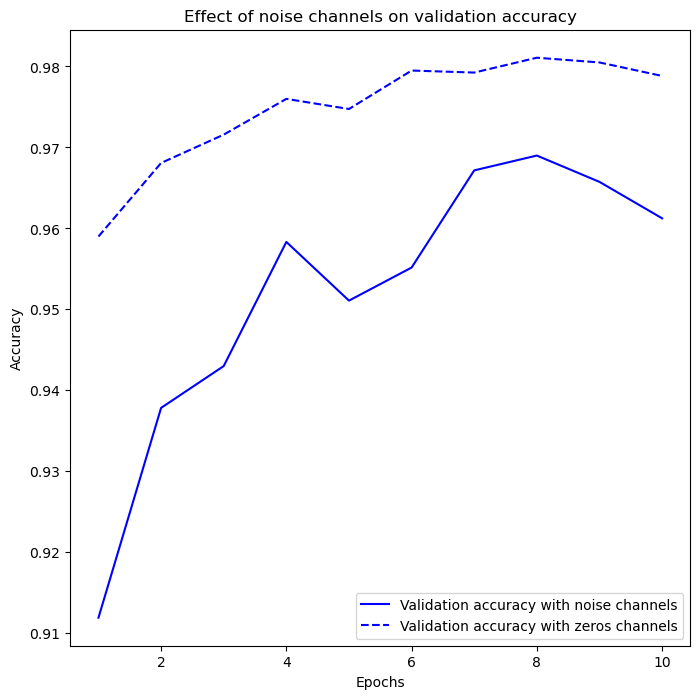

In [6]:
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
         label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
         label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();

Despite the data holding the same information in both cases, the validation accuracy
of the model trained with noise channels ends up about one percentage point lower, 
purely through the influence of spurious correlations. The more
noise channels you add, the further accuracy will degrade. 
**Noisy features inevitably lead to overfitting.**

As such, a common data exploration step in machine learning is to do a
**feature selection** or **feature importance** determination.  Restricting the
IMDB data to the top 10,000 most common words was a form of feature selection.
The typical way to do feature selection is to compute some usefulness score for each
feature available, a measure of how informative the feature is with respect to the
label.

### 5.1.2 The nature of generalization in deep learning

A remarkable fact about deep learning models is that they can be trained to fit anything,
as long as they have enough representational power.

Just to prove it, if you randomly shuffle the lables of the MNIST dataset and train a model
(of sufficient power) on that, the training loss will go down just fine and look normal.
The validation loss will not improve since there is no possibility of generalization for
random data.

In [7]:
# get the mnist training data
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

# copy the labels and randomly shuffle them
random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)


model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# the validation_split will split 20% of the data and use
# it for loss validation
history = model.fit(train_images, random_train_labels,
                    epochs=100,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1043 - loss: 2.3293 - val_accuracy: 0.1082 - val_loss: 2.3047
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1187 - loss: 2.2975 - val_accuracy: 0.1044 - val_loss: 2.3076
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1309 - loss: 2.2875 - val_accuracy: 0.1026 - val_loss: 2.3171
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1428 - loss: 2.2760 - val_accuracy: 0.1045 - val_loss: 2.3250
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1563 - loss: 2.2601 - val_accuracy: 0.1053 - val_loss: 2.3323
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1702 - loss: 2.2385 - val_accuracy: 0.1027 - val_loss: 2.3465
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1889 - loss: 2.2141 - val_accuracy: 0.1053 - val_loss: 2.3633
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2022 - loss: 2.1858 - val_accu

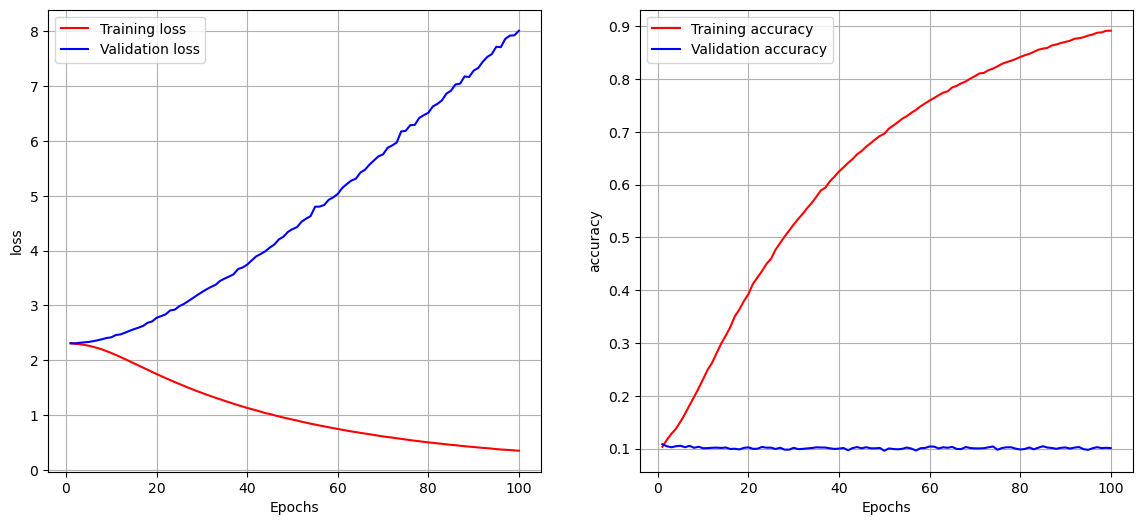

In [8]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

Training loss actually looks about the same as if you trained on real data.  Training accuracy is not as high as you would expect
to see on MNIST, because randomly shuffling the labels makes it tougher to find any actual patterns (it is only learning the noise in
the training data).

For data that has no information you migh see accuracy and loss curves like this.  For example though the accuracy improves on the data
it is learning the noise for, actual generalization accuracy on unseen validation data always remains at 10% or random guess
level.

How come deep learning models generalize at all? Shouldn’t
they just learn an ad hoc mapping between training inputs and targets, like a fancy
dict?  The nature of generalization in deep learning has rather little to do
with deep learning models themselves, and much to do with the structure of information
in the real world.

#### The manifold hypothesis

#### Interpolation as a source of generalization

#### Why deep learning works

#### Training data is paramount

## 5.2 Evaluating Machine Learning Models

You can only control what you can observe.

### 5.2.1 Training, validation and test sets

You train on the training data and evaluate your model while fitting it and while
comparing alternative models on the validation data. Once your model is ready for
prime time, you test it one final time on the test data, which is meant to be as
similar as possible to production data. Then you can deploy the model in production.

Developing a model always involves tuning its configuration.  You do this tuning by using
a feedback signal: the performance of the model on the validation data.  

Tuning the configuration of a model or multiple modles based on its performance
on the validation set can quickly result in *overfitting to the validation set*,
even though your model is never directly trained on it.  

But we care about performance on completely new data, not test data, and not the
validation data we are using to try and optimize the model architecture.  This is
why a completely different, never-before-seen dataset is needed to evaluate a
final model, the test dataset.

#### Simple holdout validation

In order to prevent information leaks, you shouldn’t tune your model based on the test set, and therefore you
should also reserve a validation set.

A simple implementaiton of holdout validation can be done as follows (this is random data, just for illustration).

```python
# data with 100,000 samples of 50 features for illustration
num_validation_samples = 10000
all_train_datadata = np.random.random((100000, 50))

# shuffling the data is usually appropriate, it could be sorted or orderd when you get it
# default behavior of np.random.shuffle on a tensor is to only shuffle the 0-th (sample) dimension
np.random.shuffle(all_train_data)


# define the validation set, slize the first 0-num_validation_samples from the data for validation
validation_data = all_train_data[:num_validation_samples]

# define the training set, use remaining data after split
train_data = all_train_datadata[num_validation_samples:]

# train a model on the training data and evaluatte it on the validation data
model = get_model()
model.fit(training_data, ...)
validation_score = model.evaluate(validation_data, ...)

# at this point you look at validation_score performance on validation data, and tune your
# model and model parameters.  Then retrain it and evaluate again, repeat
# as necessary until satisfied with performance

# once you've tuned your hyperparameters, its common to train your final
# model from stratch on all non-test data available
model = get_model()
model.fit(all_train_data, ...)
test_score = model.evaluate(test_data, ...)
```

#### K-fold validation

With this approach, you split your data into `K` partitions of equal size. For each partition
`i`, train a model on the remaining `K - 1` partitions, and evaluate it on partition `i`.
Your final score is then the averages of the K scores obtained.

This method is helpful when the performance of your model shows significant variance based on your train/test
split.

A simple pseudo code implementaiton by hand of K-fold validation looks like the following

```python
# data with 100,000 samples of 50 features for illustration
all_train_datadata = np.random.random((100000, 50))

# number of folds to divide data into
k = 3

# integer division will divide data into as equal sized partitions as possible, though
# last fold can have a few extra with this method
num_validation_samples = len(data) // k
```

In [9]:
# for instance, the size of the folds when we have around 100,000 samples would be
print(99999 // 3)  # all folds exactly equal in size
print(100000 // 3) # last fold has 1 extra sample
print(100001 // 3) # last fold has 2 extra samples
print(100002 // 3) # all folds exactly equal again

33333
33333
33333
33334


```python
# always a good idea to shuffle data in case it is sorted or ordered
np.random.shuffle(all_train_data)

# keep results for each fold validation to be reported and averged at end
validation_scores = []

# in k-fold validation, we perform a number of separate trainings of the model equal to k
for fold in range(k):
    # selects the validation-data partition from all of the data
    validation_data = data[num_validation_samples * fold: num_validation_samples * (fold + 1)]

    # combine remainder of the data for the training set
    training_data = np.concatenate(
        data[:num_validation_samples * fold],
        data[num_validation_samples * (fold + 1):]
    )

    # make sure you create a brand new instance of a model, can be easy to continue
    # training a previously trained model using keras if don't specificly create new model
    # with randomly initialized weights
    model = get_model()
    model.fit(training_data, ...)

    # use validation data to evaluate this fold
    validation_score = model.evaluate(validation_data, ...)
    validation_scores.append(validation_score)

# after k folds of training and evaluation on held back validation data,
# a better measure of generalization is the average of the individual validation scores
validation_score = np.average(validation_scores)

# train a new final model on all non-test data available and evaluate with the final test data
model = get_model()
model.fit(all_train_data, ...)
test_score = model.evaluate(test_data, ...)
```

#### Iterated K-fold validation with shuffling

This one is for situations in which you have relatively little data available and you need
to evaluate your model as precisely as possible. It consists of applying K-fold validation
`P` times, shuffling the data every time before splitting `K` ways.  The final score is the 
average of the `P` runs of K-fold validation.  Note that you end up training and
evaluation `P * K` models.

In essence, if you turned the K-fold validation code into a function that you could call, that would return
the average validation score as a result, and the function shuffled the data passed in each
time before dividing into folds, you could call this function `P` times to perform
iterated K-fold validation.

### 5.2.2 Beating a common-sense baseline

Before you start working with a dataset, you should always pick
a trivial baseline that you’ll try to beat.

### 5.2.3 Things to keep in mind about model evaluation

- **Data representativeness** You want both your training set and test set to be representative of the data at hand.
  For this reason you usually should at least **randomly shuffle** your data before splitting it into training and test sets.
- **The arrow of time** On the other hand, f you are doing time series prediction, you should **NOT** randomly shuffle your data
  before splitting it, this will cause **temporal leak**.  Instead always make sure all data in test set is *posterior* to the
  data in the training set.
- **Redundancy in your data** Be careful of repeated data points appearing multiple times in a dataset (not uncommon).  If you
  split a repeated sample and end up with it in the train and test set, you'll be leaking information and essentially testing
  with part of the data you trained with.

## 5.3 Improving model fit

To achieve the perfect fit, you must first overfit. Since you don’t know in advance
where the boundary lies, you must cross it to find it.

Thus your initial goal as you start on a problem is to achieve a model that shows some
generalization power and that is able to overfit.  Once you have such a model, you'll focus
on refining generalization by fighting overfitting.

There are 3 common problems you'll encounter when starting:

1. Training doesn’t get started: your training loss doesn’t go down over time.
2. Training gets started just fine, but your model doesn’t meaningfully generalize:
   you can’t beat the common-sense baseline you set.
3. Training and validation loss both go down over time, and you can beat your
   baseline, but you don’t seem to be able to overfit, which indicates you’re still
   underfitting.

### 5.3.1 Tuning key gradient descent parameters

Sometimes training doesn’t get started, or it stalls too early. Your loss is stuck. This is
always something you can overcome. When this happens, it’s always a problem with the configuration of the gradient
descent process: your choice of optimizer, the distribution of initial values in the
weights of your model, your learning rate, or your batch size. All these parameters are
interdependent, and as such it is usually sufficient to tune the learning rate and the
batch size while keeping the rest of the parameters constant.

Let's look at a concrete example of what we are talking about here.  Let's train MNIST model
from before with an inappropriately large learning rate value of 1.  The training loss might decrease
a bit, but it will quickly stop, and maybe even increase on the training data, which indicates
divergence.

In [8]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# notice the parameter to RMSprop, this sets the learning rate to 1
model.compile(optimizer=keras.optimizers.RMSprop(1.),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

I0000 00:00:1748969435.377522   35383 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1748969436.949566   35642 service.cc:152] XLA service 0x76e43c014950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748969436.949651   35642 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1748969437.015046   35642 cuda_dnn.cc:529] Loaded cuDNN version 90300


 58/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4697 - loss: 8195.5889 

I0000 00:00:1748969439.403571   35642 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3801 - loss: 2037.8453 - val_accuracy: 0.2109 - val_loss: 2.1834
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2006 - loss: 3.3451 - val_accuracy: 0.2104 - val_loss: 2.1921
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2020 - loss: 2.4569 - val_accuracy: 0.2069 - val_loss: 2.1647
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2047 - loss: 2.3915 - val_accuracy: 0.2214 - val_loss: 2.1447
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2040 - loss: 2.4025 - val_accuracy: 0.2052 - val_loss: 2.3822
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2109 - loss: 2.3244 - val_accuracy: 0.2601 - val_loss: 2.1328
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2304 - loss: 2.4131 - val_accuracy: 0.2266 - val_loss: 2.0766
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2320 - loss: 2.3155 - val_accuracy: 0.2245 - v

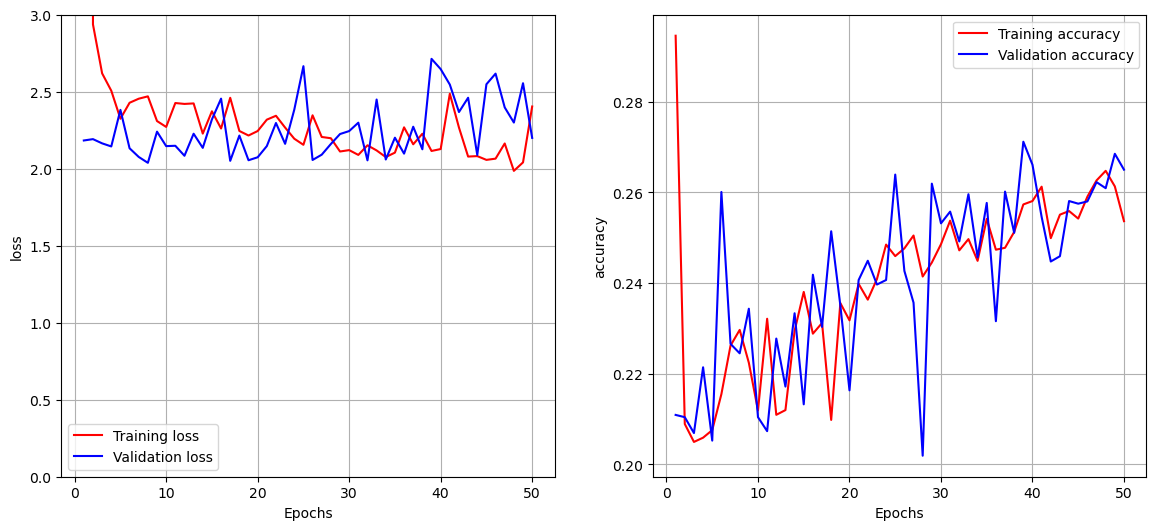

In [9]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

The model quickly reaches a training validation accuracy in the 30% range, but cannot get past that.  Let's lower the learning rate to a
more reasonable value of `1e-2`.

In [10]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# only difference from before, set learning rate to 0.01
model.compile(optimizer=keras.optimizers.RMSprop(1e-2),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8315 - loss: 0.7540 - val_accuracy: 0.9556 - val_loss: 0.1538
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9624 - loss: 0.1261 - val_accuracy: 0.9629 - val_loss: 0.1531
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - loss: 0.0908 - val_accuracy: 0.9686 - val_loss: 0.1356
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9787 - loss: 0.0801 - val_accuracy: 0.9715 - val_loss: 0.1418
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9824 - loss: 0.0669 - val_accuracy: 0.9700 - val_loss: 0.1743
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9851 - loss: 0.0571 - val_accuracy: 0.9723 - val_loss: 0.1792
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9875 - loss: 0.0502 - val_accuracy: 0.9697 - val_loss: 0.1890
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9902 - loss: 0.0404 - val_accuracy: 0.

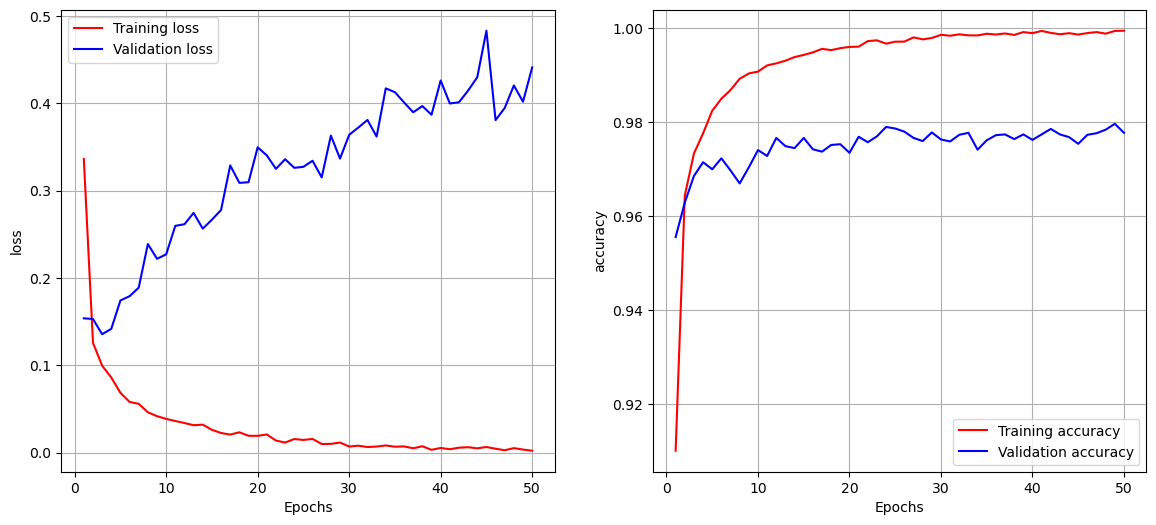

In [11]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
#ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

These learning curves look much more reasonable.  Not only is accuracy much better, but the training loss actually steadly decreases
for 30 epochs or so, indicating that it is fiting the data.

If you find yourself in a similar situation, try:

- Lowering or increasing the learning rate. A learning rate that is too high may
  lead to updates that vastly overshoot a proper fit, like in the preceding example,
  and a learning rate that is too low may make training so slow that it appears
  to stall.
- Increasing the batch size. A batch with more samples will lead to gradients that
  are more informative and less noisy (lower variance).

### 5.3.2 Leveraging better architecture priors

### 5.3.3 Increasing model capacity

If your model seems to be fitting the training data, and your validation metrics are going down and it seems to achieve at least some level
of generalization, then, you next need to get your model to start overfitting.

For example, consider using a simple logistic regression trained on MNIST dataset.

In [12]:
# remember that a logistic regression is really equivalent to a
# neural network with a single layer performing a tensor multiple
# of weight parameters and a tensor addition to the bias parameters
model = keras.Sequential([layers.Dense(10, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(train_images, train_labels,
                                epochs=20,
                                batch_size=128,
                                validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7399 - loss: 1.0377 - val_accuracy: 0.9041 - val_loss: 0.3606
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8992 - loss: 0.3684 - val_accuracy: 0.9154 - val_loss: 0.3105
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9119 - loss: 0.3241 - val_accuracy: 0.9197 - val_loss: 0.2922
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9154 - loss: 0.3024 - val_accuracy: 0.9192 - val_loss: 0.2855
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9181 - loss: 0.2964 - val_accuracy: 0.9235 - val_loss: 0.2776
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9219 - loss: 0.2864 - val_accuracy: 0.9219 - val_loss: 0.2771
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9228 - loss: 0.2726 - val_accuracy: 0.9250 - val_loss: 0.2718
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.2708 - val_accuracy: 0.

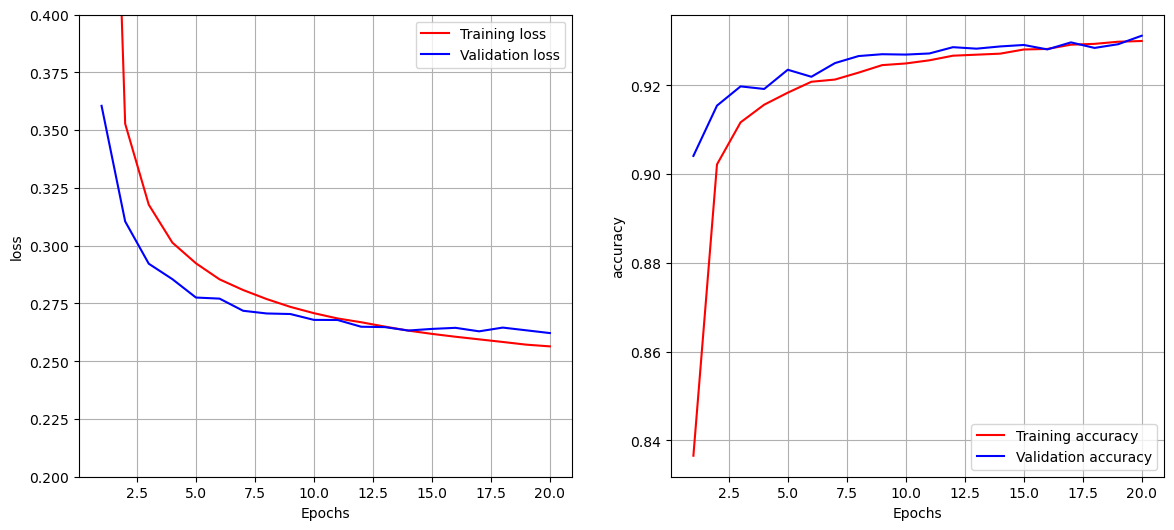

In [13]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_small_model.history, 'loss')
ax_loss.set_ylim(0.2, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_small_model.history, 'accuracy')

What we are looking at here is the validation loss.  Validation loss seem to stall or are improving very slowly.
Instead if the model is sufficiently powerful, we would expect overfitting.  The validation loss
goes to 0.26 and just stays there.  You can fit, but you can't clearly overfit.

The sign of a model that is overfitting is that validation loss will go down to some minimum, but will begin to increase again
once overfitting begins to occur.  Remember that it should always be possible to overfit.  We saw that a neural
network can fit random data if you tell it to. If you can't seem to be able to overfit, it's likely a problem
with the **representational power** of your model. You need a bigger model with more **capacity**.

You can increate representational power by adding more layers, using bigger layers, or using kinds of
layers more appropriate to the problem.

For example, if we use a bigger model we can easily get the model to overfit.

In [14]:
model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_large_model = model.fit(
    train_images, train_labels,
    epochs=40,
    batch_size=128,
    validation_split=0.2)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8273 - loss: 0.6246 - val_accuracy: 0.9476 - val_loss: 0.1834
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9497 - loss: 0.1710 - val_accuracy: 0.9622 - val_loss: 0.1320
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9652 - loss: 0.1161 - val_accuracy: 0.9627 - val_loss: 0.1228
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9746 - loss: 0.0850 - val_accuracy: 0.9694 - val_loss: 0.1056
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9791 - loss: 0.0685 - val_accuracy: 0.9692 - val_loss: 0.1006
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0578 - val_accuracy: 0.9721 - val_loss: 0.0965
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9855 - loss: 0.0459 - val_accuracy: 0.9720 - val_loss: 0.0955
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9882 - loss: 0.0380 - val_accuracy: 0.

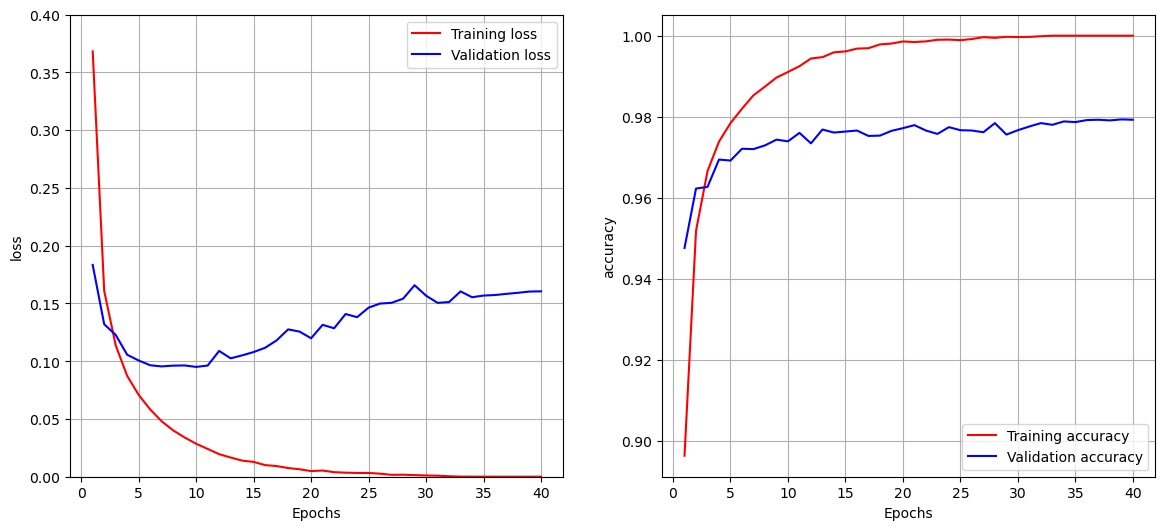

In [15]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_large_model.history, 'loss')
ax_loss.set_ylim(0.00, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_large_model.history, 'accuracy')

The validation loss for a model with appropriate capacity looks something like the loss figure here.  
Training loss continues to improve steadily.  But validation loss decreases till epoch 5 to 10,
then clearly begins to creep back up again.  The model is overfitting here, learning the
noise in the data which decreases generalization.

## 5.4 Improving generalization

Once your model has shown itself to have some generalization power and to be able
to overfit, it’s time to switch your focus to maximizing generalization

### 5.4.1 Dataset curation

### 5.4.2 Feature engineering

### 5.4.3 Using early stopping

### 5.4.4 Regularizing your model

Regularization techniques are a set of best practices that actively impede the model’s ability
to fit perfectly to the training data, with the goal of making the model perform better
during validation.

#### Reducing the network's size

The simplest way to mitigate overfitting when working with neural networks is to reduce the size of the model.
That is to say, reduce the number of learnable parameters available to the model, which is determined by
the number of layers and the number of hidden units in each layer. If the model has limited memorization resources, it won’t be able to
simply memorize its training data; thus, in order to minimize its loss, it will have to
resort to learning compressed representations that have predictive power regarding
the targets.

At the same time, keep in mind that you should use models that have enough parameters that they
don’t underfit: your model shouldn’t be starved for memorization resources. There is
a compromise to be found between too much capacity and not enough capacity.

There is no real formula to determine the right size and capacity for your model.  You have to 
evaluate a sample of different architectures (on your validation set) in order to find a good range of 
capacity for your problem.  The general workflow is to start with relatively few layers and parameters,
and increase the size of the layers or add new layers until you see diminishing returns with regard
to validation loss.

Lets try this approach on the movie-review binary classification model.  Here is the original model
from the previous unit.

In [4]:
from tensorflow.keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

train_data = vectorize_samples(train_data)

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_original = model.fit(train_data, train_labels,
                             epochs=20, batch_size=512, validation_split=0.4)

I0000 00:00:1748969773.024245   45811 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/20


I0000 00:00:1748969776.835068   45982 service.cc:152] XLA service 0x77f634003810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748969776.835123   45982 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1748969776.962942   45982 cuda_dnn.cc:529] Loaded cuDNN version 90300


21/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6542 - loss: 0.6467

I0000 00:00:1748969778.491275   45982 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.6877 - loss: 0.6216 - val_accuracy: 0.8668 - val_loss: 0.4076
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8822 - loss: 0.3586 - val_accuracy: 0.8836 - val_loss: 0.3176
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9177 - loss: 0.2582 - val_accuracy: 0.8902 - val_loss: 0.2858
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9384 - loss: 0.1992 - val_accuracy: 0.8900 - val_loss: 0.2758
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9460 - loss: 0.1653 - val_accuracy: 0.8895 - val_loss: 0.2770
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9604 - loss: 0.1348 - val_accuracy: 0.8794 - val_loss: 0.3009
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9633 - loss: 0.1232 - val_accuracy: 0.8843 - val_loss: 0.2990
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9735 - loss: 0.1013 - val_accuracy: 0.8863 - val_loss: 0

Now lets train a smaller model so that we can compare the effect on the validation loss of the original
larger model with a smaller model.

In [5]:
model = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_smaller_model = model.fit(train_data, train_labels,
                                  epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.6638 - loss: 0.6593 - val_accuracy: 0.8342 - val_loss: 0.5579
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8522 - loss: 0.5268 - val_accuracy: 0.8615 - val_loss: 0.4667
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8810 - loss: 0.4315 - val_accuracy: 0.8726 - val_loss: 0.4002
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8955 - loss: 0.3583 - val_accuracy: 0.8758 - val_loss: 0.3583
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9069 - loss: 0.3069 - val_accuracy: 0.8832 - val_loss: 0.3220
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9221 - loss: 0.2574 - val_accuracy: 0.8869 - val_loss: 0.2987
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9293 - loss: 0.2272 - val_accuracy: 0.8867 - val_loss: 0.2861
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9383 - loss: 0.1991 - val_accuracy: 0.8862 - v

Lets compare the validation loss of the original larger model to this smaller model.

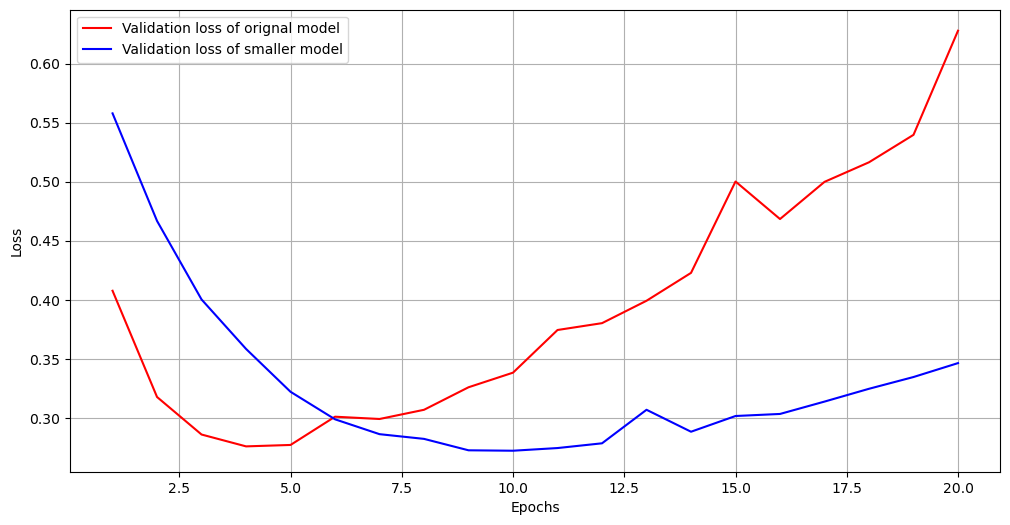

In [6]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of orignal model')
plt.plot(epochs, history_smaller_model.history['val_loss'], 'b-', label='Validation loss of smaller model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

As you should normally see, the smaller model is overfitting, but later than the original model, and its performance degrades
more slowly once it starts overfitting.

Now lets add in a model with even more capacity than the original model, far more than the problem warrants.  
While it is standard to work with models that are significantly overparameterized for what they're trying to learn,
there can definitely be such a thing as too much memorization capacity. You'll know your model is too large
if it starts overfitting right away and if its validation loss curve looks choppy with high variance.

Here is a model with larger capacity than the original.

In [7]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_larger_model = model.fit(train_data, train_labels,
                                 epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 285ms/step - accuracy: 0.6388 - loss: 0.6369 - val_accuracy: 0.8656 - val_loss: 0.3415
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8683 - loss: 0.3268 - val_accuracy: 0.8818 - val_loss: 0.2999
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9174 - loss: 0.2250 - val_accuracy: 0.8794 - val_loss: 0.2975
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9273 - loss: 0.1856 - val_accuracy: 0.8817 - val_loss: 0.2941
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9440 - loss: 0.1425 - val_accuracy: 0.8305 - val_loss: 0.4144
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9675 - loss: 0.0962 - val_accuracy: 0.8845 - val_loss: 0.3317
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9763 - loss: 0.0777 - val_accuracy: 0.8857 - val_loss: 0.3636
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9804 - loss: 0.0661 - val_accuracy: 0.8865 -

Here are all three models validation loss for comparison.

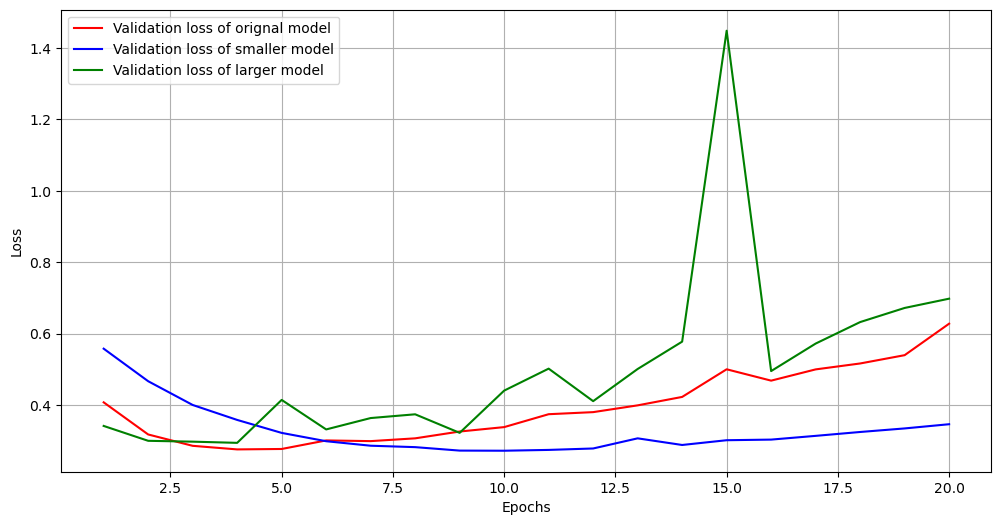

In [8]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of orignal model')
plt.plot(epochs, history_smaller_model.history['val_loss'], 'b-', label='Validation loss of smaller model')
plt.plot(epochs, history_larger_model.history['val_loss'], 'g-', label='Validation loss of larger model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

The larger model will usually when you rerun these cells start overfitting and increasing loss before the original and small
models.  Also its validation loss will often look noiser.  If you look at the training loss from this large model, 
it essentially gets driven to 0 after 10 epochs or so.  The more capacity the model has, the more quickly it
can model the training data (resulting in low training loss), but the more susceptible it is to overfitting.

#### Adding weight regularization

Given some training data and a given network architecture with a given set of trainable parameters, multiple settings of
the parameters can be uilt that will explain / model the data.  "Simpler: models are less likely to overfit
than complex ones.  So regularization are ways to constrain training to prefer "simpler" models to be learned for
the training data.

A **simple model** in this context is a model where the distribution of parameter values
has less entropy.  Thus, a common way to mitigate overfitting is to put constraints on the complexity
of a model by forcing its weights to take only small values, which makes the distribution of weight
values more **regular**.

This is called **weight regularization** and it is done by adding to the loss function of the model a cost associated with
having large weights.  There are two common loss penalties used for regularization:

- L1 regularization—The cost added is proportional to the absolute value of the
  weight coefficients (the L1 norm of the weights).
- L2 regularization—The cost added is proportional to the square of the value of the
  weight coefficients (the L2 norm of the weights).

In `keras` weight regularization is added by passing **weight regularizer instances**
to layers as keyword arguments.  Let's show the effect of adding L2 weight regularization
to our original movie-review binary classification model.

In [9]:
from tensorflow.keras import regularizers

model = keras.Sequential([
    layers.Dense(16, 
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(16, 
                 kernel_regularizer=regularizers.l2(0.002),
                 activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_l2_reg = model.fit(train_data, train_labels,
                           epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.7020 - loss: 0.6704 - val_accuracy: 0.8580 - val_loss: 0.4678
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8938 - loss: 0.4090 - val_accuracy: 0.8853 - val_loss: 0.3855
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9166 - loss: 0.3286 - val_accuracy: 0.8669 - val_loss: 0.3960
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9202 - loss: 0.3018 - val_accuracy: 0.8879 - val_loss: 0.3544
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9402 - loss: 0.2619 - val_accuracy: 0.8542 - val_loss: 0.4257
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9350 - loss: 0.2576 - val_accuracy: 0.8847 - val_loss: 0.3582
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9493 - loss: 0.2349 - val_accuracy: 0.8772 - val_loss: 0.3833
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9539 - loss: 0.2224 - val_accuracy: 0.8818 - 

In this example, as you can see, the regularization is added to both layers using `regularizers.l2(0.002)`.
The value `0.002` is the alpha paramter that controls the effect that the regularization penality has
with respect to the loss function.  So the layer will effectively add `0.002 * weight_coefficient_value**2` to every
weight.  The larger the weight, the larger this penality is, thus increasing the loss.

**Note**: When using regularization, the penality is only added at training time.  So the training loss will be 
(possibly much) higher than what the validation loss appears to be when you are using regularization.

Again lets look at the effect of regularization on this model.  Here we show this new model using L2
regularization against the original model, and the effect the regularization has on the validation loss.

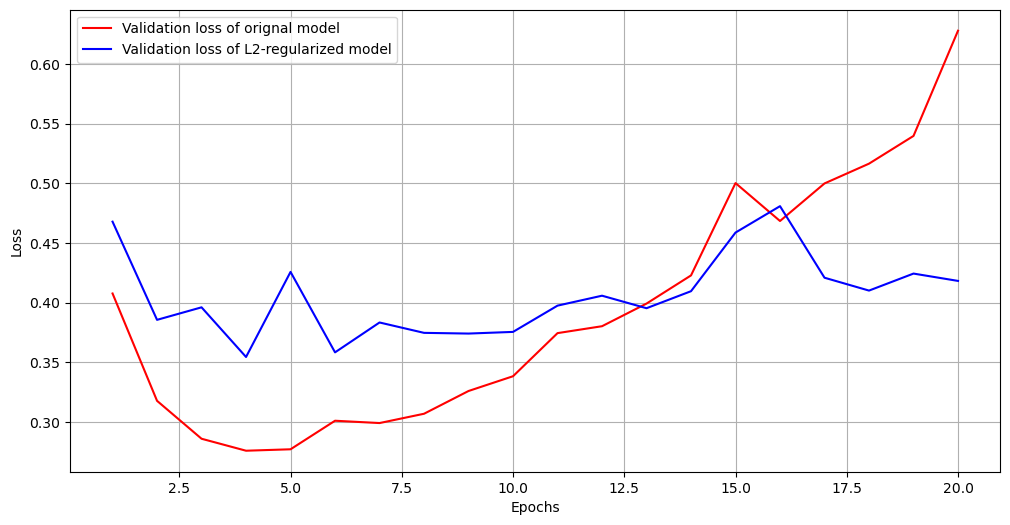

In [10]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of orignal model')
plt.plot(epochs, history_l2_reg.history['val_loss'], 'b-', label='Validation loss of L2-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

As you should usually see, the model with L2 regularization has become more resistant to overfitting.  Overfitting
occurs later in the training epochs and proceeds more slowly, even though both models have the same
capacity (same number of trainable parameters).

As an alternative to L2 regularization, you can use L1 regularization (which computes the
error using the absolute value of the weights), or you can combine and use both L1 and
L2 regularization together.

```python
from tensorflow.keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# simultaneous L1 and L2 regularization
regularizers.l1_l2(l1=0.001, l2=0.001)
```

Note that weight regularization is more typically used for smaller deep learning models.  Large
deep learningmodels tend to be so overparameterized that imposing constraints on weight values
hasn't much impact on model capacity and generalization.  In these cases, a different 
regularization technieque is prefered for neural network like models: dropout.

#### Adding dropout

**Dropout** is one of the most effective and most commonly used regularization techniques
for neural networks.  Dropout, applied to a layer, consists of randomly dropping out
(setting to zero) a number of output features of the layer during training.
The dropout rate is the fraction of the features that are zeroed out.

Just as ane example, if the dropout rate is 50%, and we have the output tensor
from a layer named `layer_output`, we could simulate random dropout doing
somethig like the following:

In [11]:
# to illustrate, an output layer has shape 5 samples by 10 features (5, 10)
layer_output = np.random.randn(5, 10)
print(layer_output)

[[ 0.9414 -1.9972  0.7918 -1.1718  1.5227  1.2055 -1.8637 -1.1647  0.224
  -0.9456]
 [ 0.5222  1.6337 -0.1185 -0.4089  1.2845 -0.2363 -2.2643 -0.6682 -1.4777
   1.1976]
 [ 0.6873  0.3189 -0.5295  0.2645 -0.8994  0.7094  0.7445 -0.2367  0.3436
  -0.019 ]
 [-0.9263  1.0637  0.4578 -0.7183 -1.9822 -0.8085  1.8449  1.4383 -0.1767
  -0.7241]
 [ 0.7925  1.1576  0.0264  0.6201  0.0919 -0.7245 -2.3623 -1.0755  1.1857
  -0.5822]]


In [12]:
# generate a random matrix of random intigers of the same shape, 50% 0 and 50% 1
dropout_mask = np.random.randint(0, high=2, size=layer_output.shape)
print(dropout_mask)

[[1 1 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 1 0 0 1]
 [0 1 0 1 1 0 0 1 0 1]
 [0 1 1 0 1 0 0 0 0 0]
 [0 1 0 1 0 1 1 1 0 1]]


In [13]:
# multiplying by mask randomly drops out 50% of the output values
layer_output_dropped = layer_output * dropout_mask
print(layer_output_dropped)

[[ 0.9414 -1.9972  0.     -0.      0.      0.     -0.     -0.      0.224
  -0.    ]
 [ 0.      0.     -0.     -0.      0.     -0.2363 -2.2643 -0.     -0.
   1.1976]
 [ 0.      0.3189 -0.      0.2645 -0.8994  0.      0.     -0.2367  0.
  -0.019 ]
 [-0.      1.0637  0.4578 -0.     -1.9822 -0.      0.      0.     -0.
  -0.    ]
 [ 0.      1.1576  0.      0.6201  0.     -0.7245 -2.3623 -1.0755  0.
  -0.5822]]


At test time, we scale down the output by the dropout rate.  So if we were
using a 50% dropout, when we do predictions for testing, all weights would
be scaled down by 50%.  This is because the size of the weights learned with
dropouts will be 50% larger than if no dropout were used.  So to
compensate once we finish training, we scale down by the same amount so
that we get a similar output level as we do when dropout is being applied.

In [14]:
# At test time, when making predictions, scale down output
layer_output = layer_output * 0.5
print(layer_output)

[[ 0.4707 -0.9986  0.3959 -0.5859  0.7614  0.6028 -0.9319 -0.5823  0.112
  -0.4728]
 [ 0.2611  0.8169 -0.0592 -0.2044  0.6423 -0.1182 -1.1321 -0.3341 -0.7388
   0.5988]
 [ 0.3436  0.1594 -0.2648  0.1323 -0.4497  0.3547  0.3723 -0.1183  0.1718
  -0.0095]
 [-0.4631  0.5319  0.2289 -0.3592 -0.9911 -0.4042  0.9225  0.7192 -0.0883
  -0.3621]
 [ 0.3963  0.5788  0.0132  0.3101  0.0459 -0.3622 -1.1811 -0.5378  0.5929
  -0.2911]]


Note that this process can be implemented by doing both operations at training
time, and leaving the output unchanged at test time, which is often the
way it's implemented in practice.

This technique may not make sense to you at first thought, how does
randomly zeroing out output results during training improve
generaliztion of the network while learning?  The core idea is that introducing
noise in the output values of a layer can break up happenstance patterns that aren’t significant.

In `keras` we can introduce dropout regularization to a model by inserting `Dropout` layers
in the network architecture. A `Dropout` layer is applied to the output of the
layer immediately preceeding it.  Let's add `Dropout` layers in the IMDB model
to see how well they do at reducing overfitting.

In [15]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.5920 - loss: 0.6622 - val_accuracy: 0.8457 - val_loss: 0.5224
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7559 - loss: 0.5305 - val_accuracy: 0.8662 - val_loss: 0.4063
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8192 - loss: 0.4382 - val_accuracy: 0.8794 - val_loss: 0.3383
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8583 - loss: 0.3703 - val_accuracy: 0.8849 - val_loss: 0.3031
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8770 - loss: 0.3244 - val_accuracy: 0.8853 - val_loss: 0.2880
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9007 - loss: 0.2839 - val_accuracy: 0.8872 - val_loss: 0.2778
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9112 - loss: 0.2562 - val_accuracy: 0.8916 - val_loss: 0.2744
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9252 - loss: 0.2226 - val_accuracy: 0.8919 - 

And again lets compare the effect of dropout regularization on validation loss with what the original
model without dropout was doing.

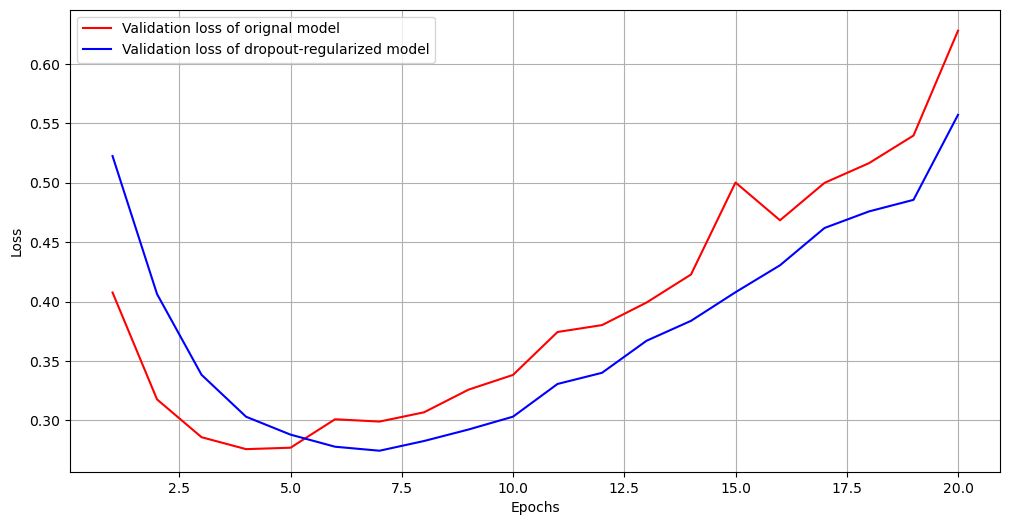

In [16]:
plt.figure(figsize=(12,6))
epochs = np.arange(1, len(history_original.history['val_loss']) + 1)
plt.plot(epochs, history_original.history['val_loss'], 'r-', label='Validation loss of orignal model')
plt.plot(epochs, history_dropout.history['val_loss'], 'b-', label='Validation loss of dropout-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend();

Usually you will see a similar effect as with the L1/L2 regularization.  Overfitting will occur later and validation loss will
degrade slower than for the unregularized original model.

To recap, here is what you should remember about the most common ways to maximize generalization and
prevent overfitting in neural network models:

<font color='blue'>

- Get more training data, or better training data.
- Develop better features.
- Reduce the capacity of the model.
- Add weight regularization (for smaller models).
- Add dropout.

# Chapter Summary

Things to remember about fundamental Machine Learning concepts in the context of training neural networks and
deep network models:

<font color='blue'>

- The purpose of a machine learning model is to generalize: to perform accurately
  on never-before-seen inputs.
- A deep neural network achieves generalization by learning a parametric model
  that can successfully interpolate between training samples (learning a latent manifold).
- The fundamental problem in machine learning is the tension between optimization
  and generalization.  To again generalization you must first achieve a good
  fit to the model, but improving a models fit (training loss) will inevitably start
  hurting generalization.  **Every single deep learning best practice deals with managing this tension**.
- The ability of deep learning models to generalize comes from the fact that they
  manage to learn to approximate the latent manifold of their data, and can thus
  make sense of new inputs via interpolation.
- It’s essential to be able to accurately evaluate the generalization power of your
  model while you’re developing it.
  - Simple holdout validation
  - K-fold cross-validation and iterated K-fold cross-validation (especially when size of data is small)
  - Test set needs to be kept for final model evaluation, not used when validating models.
- When you start working on a model, your goal is first to achieve a model that
  has some generalization power and that can overfit.
- As your model starts overfitting, your goal switches to improving generalization
  through model regularization. You can reduce your model’s capacity, add dropout
  or weight regularization, and use early stopping. And naturally, a larger or better
  dataset is always the number one way to help a model generalize.